# Ablation Study — KD Temperature $T$ (and, optionally, $\lambda$)

Rubric requirement: *"at least one meaningful ablation on T, λ, or Δ"*. This notebook sweeps $T$ with every other hyperparameter held fixed at the values in `StudentKDQATConfig`, training a fresh student from scratch for each value.

**Hypothesis:** very low $T$ (≈1) gives the student almost no extra information beyond the hard labels (the teacher's softmax is already close to one-hot), so KD should behave similarly to plain supervised training. Very high $T$ over-smooths the teacher's distribution, potentially washing out genuinely useful class-similarity information. A moderate $T$ (commonly 2–8 in the KD literature) is expected to work best — but this must be checked empirically here, not assumed.

**Note on compute budget:** ablation runs use `AblationConfig.ablation_epochs` (fewer epochs than the final full training run in Notebook 03) — a standard, explicit trade-off for *relative* comparison across settings under limited compute. State this in your report; do not treat these as your best final numbers.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
from src.utils import set_seed, get_device, plot_training_curves

set_seed(42)
device = get_device()
print("Using device:", device)


Using device: cuda


In [2]:
from src.data import get_cifar10_loaders

train_loader, val_loader, test_loader = get_cifar10_loaders(
    data_dir="../data", batch_size=128, val_fraction=0.1, num_workers=2, seed=42
)


In [3]:
from src.resnet_cifar import resnet34_cifar, resnet18_cifar
from src.ternary import TernaryConv2d, TernaryLinear
from src.config import StudentKDQATConfig, AblationConfig

teacher = resnet34_cifar(num_classes=10)
teacher_ckpt = torch.load(StudentKDQATConfig().teacher_checkpoint, map_location=device)
teacher.load_state_dict(teacher_ckpt["model_state_dict"])
teacher.to(device)
teacher.eval()
for p in teacher.parameters():
    p.requires_grad_(False)

def student_factory():
    return resnet18_cifar(num_classes=10, conv_layer=TernaryConv2d,
                           linear_layer=TernaryLinear, first_last_fp32=True)

ablation_cfg = AblationConfig()
print("Temperature values to sweep:", ablation_cfg.temperature_values)
print("Ablation epochs per run:", ablation_cfg.ablation_epochs)


Temperature values to sweep: [1.0, 2.0, 4.0, 8.0]
Ablation epochs per run: 40


## Run the temperature ablation
$\lambda$ (`kd_alpha`) is held fixed at the default from `StudentKDQATConfig` while $T$ varies.

In [5]:
from src.kd_loss import KDLoss
from src.ablation import run_ablation

base_cfg = StudentKDQATConfig(epochs=30)          
base_cfg.checkpoint_path = "checkpoints/ablation_temperature_student.pth"

def kd_loss_factory(cfg):
    return KDLoss(temperature=cfg.temperature, alpha=cfg.kd_alpha,
                   label_smoothing=cfg.label_smoothing)

temperature_results = run_ablation(
    student_factory, teacher, train_loader, val_loader, device,
    base_cfg, kd_loss_factory,
    param_name="temperature", param_values=ablation_cfg.temperature_values,
)
temperature_results.to_csv("results/ablation_temperature.csv", index=False)
temperature_results


=== Ablation: temperature = 1.0 ===
Epoch   1/30 | quant=OFF (warmup) | train_loss 1.4666 (kd 1.3569, hard 1.7228) acc 38.19% | val_loss 2.6477 acc 13.20%
Epoch   2/30 | quant=OFF (warmup) | train_loss 0.9405 (kd 0.8653, hard 1.1161) acc 60.99% | val_loss 2.6502 acc 13.08%
Epoch   3/30 | quant=OFF (warmup) | train_loss 0.7100 (kd 0.6509, hard 0.8480) acc 71.61% | val_loss 2.4304 acc 10.08%
Epoch   4/30 | quant=OFF (warmup) | train_loss 0.5820 (kd 0.5310, hard 0.7008) acc 77.18% | val_loss 2.8314 acc 12.14%
Epoch   5/30 | quant=OFF (warmup) | train_loss 0.5074 (kd 0.4604, hard 0.6170) acc 80.54% | val_loss 2.3810 acc 19.16%
Epoch   6/30 | quant=ON | train_loss 0.5054 (kd 0.4575, hard 0.6172) acc 80.33% | val_loss 0.7255 acc 70.40%
Epoch   7/30 | quant=ON | train_loss 0.4545 (kd 0.4094, hard 0.5597) acc 82.62% | val_loss 0.4578 acc 81.34%
Epoch   8/30 | quant=ON | train_loss 0.4186 (kd 0.3753, hard 0.5194) acc 83.94% | val_loss 0.4467 acc 81.36%
Epoch   9/30 | quant=ON | train_loss 0.39

Epoch  14/30 | quant=ON | train_loss 0.3299 (kd 0.2824, hard 0.4406) acc 88.09% | val_loss 0.4528 acc 81.80%
Epoch  15/30 | quant=ON | train_loss 0.3151 (kd 0.2691, hard 0.4226) acc 88.75% | val_loss 0.4027 acc 83.66%
Epoch  16/30 | quant=ON | train_loss 0.2948 (kd 0.2501, hard 0.3991) acc 89.70% | val_loss 0.3717 acc 85.28%
Epoch  17/30 | quant=ON | train_loss 0.2769 (kd 0.2338, hard 0.3776) acc 90.35% | val_loss 0.3084 acc 87.06%
Epoch  18/30 | quant=ON | train_loss 0.2589 (kd 0.2175, hard 0.3555) acc 91.01% | val_loss 0.2757 acc 89.06%
Epoch  19/30 | quant=ON | train_loss 0.2403 (kd 0.2005, hard 0.3332) acc 91.74% | val_loss 0.2866 acc 88.64%
Epoch  20/30 | quant=ON | train_loss 0.2176 (kd 0.1797, hard 0.3061) acc 92.71% | val_loss 0.3122 acc 87.54%
Epoch  21/30 | quant=ON | train_loss 0.1990 (kd 0.1628, hard 0.2836) acc 93.42% | val_loss 0.2706 acc 89.20%
Epoch  22/30 | quant=ON | train_loss 0.1751 (kd 0.1405, hard 0.2561) acc 94.41% | val_loss 0.2333 acc 90.80%
Epoch  23/30 | quan

,temperature,best_val_acc,final_train_acc,final_kd_term,final_hard_term,checkpoint
0,1.0,93.92,99.30,0.0306,0.0947,checkpoints/ablation_temperature_student_tempe...
1,2.0,93.52,99.03,0.0402,0.1173,checkpoints/ablation_temperature_student_tempe...
2,4.0,93.38,98.86,0.0377,0.1223,checkpoints/ablation_temperature_student_tempe...
3,8.0,93.74,98.83,0.0334,0.1201,checkpoints/ablation_temperature_student_tempe...


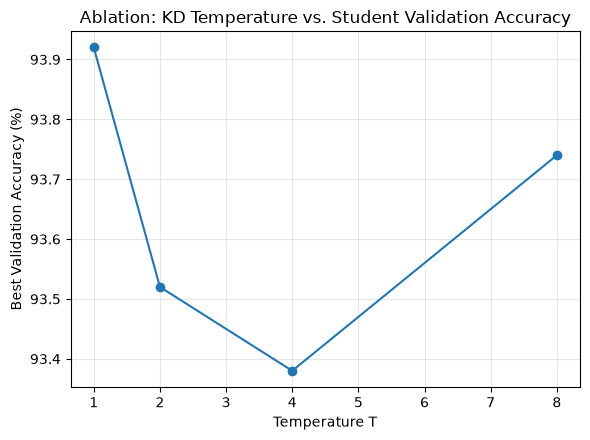

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4.5))
plt.plot(temperature_results["temperature"], temperature_results["best_val_acc"], marker="o")
plt.xlabel("Temperature T")
plt.ylabel("Best Validation Accuracy (%)")
plt.title("Ablation: KD Temperature vs. Student Validation Accuracy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/ablation_temperature_plot.png", dpi=150, bbox_inches="tight")
plt.show()
